# 06b — Autoencoder: phát hiện bất thường không giám sát (tùy chọn)

**Việc tương ứng:** T-34 trong [TASKS.md](../TASKS.md), thiết kế ở
[04 §8](../docs/04-thiet-ke-mo-hinh-ml.md). *Xong là khi:* so được PR-AUC với mô hình có giám sát
và giải thích **vì sao** nó thua.

| Mục | Thiết kế |
|---|---|
| Dữ liệu huấn luyện | **chỉ** `X_train[y_train == 0]`: mô hình học "thế nào là bình thường" |
| Kiến trúc | 31 → 16 → 8 → 16 → 31, ReLU, đầu ra tuyến tính (`MLPRegressor`, môi trường không có PyTorch) |
| Hàm mất mát | MSE tái tạo |
| Điểm rủi ro | sai số tái tạo trên tập kiểm thử |
| Đánh giá | cùng khung: PR-AUC, bootstrap theo cặp với XGBoost |

31 thay vì 30 đầu vào vì `Time` đã được thay bằng cặp `hour_sin`, `hour_cos` (DS-03).

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score, roc_auc_score

from src import plots
from src.anomaly import ReconstructionScorer
from src.config import RANDOM_STATE, REPORTS_DIR
from src.data import load_prepared, split_data
from src.evaluate import baseline_pr_auc, bootstrap_ci, bootstrap_diff
from src.features import build_features
from src.modeling import build_pipeline

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
np.random.seed(RANDOM_STATE)
N_BOOT = 1000

In [2]:
df, _ = load_prepared()
X_train_tho, X_test_tho, y_train, y_test = split_data(df, as_features=False)
X_train, X_test = build_features(X_train_tho), build_features(X_test_tho)
y_train, y_test = y_train.to_numpy(), y_test.to_numpy()
assert int(y_test.sum()) == 95

bat_dau = time.perf_counter()
ae = ReconstructionScorer().fit(X_train[y_train == 0])          # KHÔNG một nhãn gian lận nào
diem_ae = ae.score_samples(X_test)
print(f"autoencoder: {time.perf_counter() - bat_dau:.0f}s, {ae.network_.n_iter_} vòng, "
      f"dừng sớm theo tập kiểm định nội bộ (10% lớp hợp lệ)")

bat_dau = time.perf_counter()
xgb = build_pipeline("xgboost", "class_weight", y=y_train).fit(X_train, y_train)
diem_xgb = xgb.predict_proba(X_test)[:, 1]
print(f"xgboost + class_weight: {time.perf_counter() - bat_dau:.0f}s")

Số dòng        : 284,807
Số cột         : 31
Ô thiếu giá trị: 0
Dòng trùng lặp : 1,081
Gian lận       : 492 (0.173%)
Không phát hiện vấn đề.


Loại 1,081 dòng trùng lặp (0.380%), trong đó 19 mẫu gian lận. Còn lại 283,726 dòng.


autoencoder: 185s, 91 vòng, dừng sớm theo tập kiểm định nội bộ (10% lớp hợp lệ)


xgboost + class_weight: 96s


In [3]:
hang = []
for ten, s in (("autoencoder (không giám sát)", diem_ae), ("xgboost + class_weight (có giám sát)", diem_xgb)):
    pr = bootstrap_ci(y_test, s, "pr_auc", n_boot=N_BOOT, random_state=RANDOM_STATE)
    thu_tu = np.argsort(-s)
    hang.append({"mô hình": ten,
                 "PR-AUC [KTC 95%]": f"{pr['value']:.3f} [{pr['ci_low']:.3f} – {pr['ci_high']:.3f}]",
                 "ROC-AUC": round(roc_auc_score(y_test, s), 3),
                 "gian lận trong 100 điểm cao nhất": int(y_test[thu_tu[:100]].sum()),
                 "gian lận trong 500 điểm cao nhất": int(y_test[thu_tu[:500]].sum())})
display(pd.DataFrame(hang).style.hide(axis="index"))
hieu = bootstrap_diff(y_test, diem_xgb, diem_ae, n_boot=N_BOOT, random_state=RANDOM_STATE)
print(f"Hiệu PR-AUC xgboost − autoencoder: {hieu['value']:+.3f} [{hieu['ci_low']:+.3f}, {hieu['ci_high']:+.3f}], "
      f"xgboost thắng ở {hieu['a_wins']:.0%} số lần lặp")
print(f"Đường cơ sở PR-AUC: {baseline_pr_auc(y_test):.5f}")

mô hình,PR-AUC [KTC 95%],ROC-AUC,gian lận trong 100 điểm cao nhất,gian lận trong 500 điểm cao nhất
autoencoder (không giám sát),0.329 [0.246 – 0.438],0.949000,34,74
xgboost + class_weight (có giám sát),0.825 [0.747 – 0.896],0.977000,77,82


Hiệu PR-AUC xgboost − autoencoder: +0.496 [+0.394, +0.583], xgboost thắng ở 100% số lần lặp
Đường cơ sở PR-AUC: 0.00167


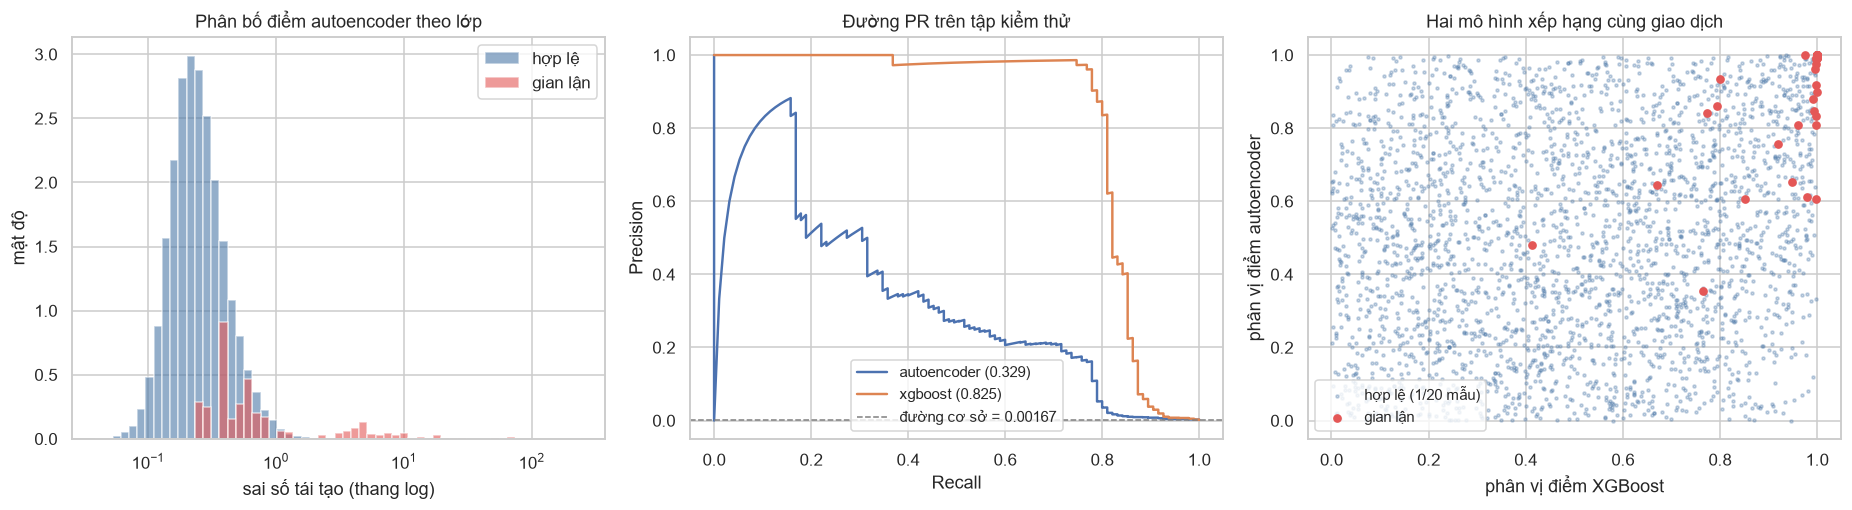

Trong 1% giao dịch 'bất thường' nhất theo autoencoder: 568 giao dịch, 74 là gian lận
Gian lận autoencoder xếp dưới trung vị (trông 'bình thường'): 2/95; trong số đó XGBoost vẫn xếp top 1%: 0

Đặc trưng tái tạo tệ nhất ở lớp gian lận so với lớp hợp lệ:


,0,1,tỷ lệ gian lận / hợp lệ
V17,0.09,119.61,1293.93
V10,0.19,45.32,232.97
V14,0.31,68.94,224.02
V12,0.37,57.64,154.94
V16,0.34,45.53,135.03
V7,0.37,31.47,85.02
V3,0.42,33.15,79.82
V5,0.24,15.12,64.33


In [4]:
# Vì sao thua: những gian lận nào autoencoder thấy "bất thường", và giao dịch hợp lệ nào cũng bất thường không kém
hang_ae = pd.Series(diem_ae).rank(pct=True).to_numpy()
hang_xgb = pd.Series(diem_xgb).rank(pct=True).to_numpy()

fig, truc = plt.subplots(1, 3, figsize=(17, 4.8))
ax = truc[0]
bins = np.logspace(np.log10(diem_ae.min()), np.log10(diem_ae.max()), 60)
for nhan, mau in ((0, "#4C78A8"), (1, "#E45756")):
    ax.hist(diem_ae[y_test == nhan], bins=bins, density=True, alpha=0.6, color=mau,
            label=plots.CLASS_LABELS[nhan])
ax.set_xscale("log")
ax.set_xlabel("sai số tái tạo (thang log)")
ax.set_ylabel("mật độ")
ax.set_title("Phân bố điểm autoencoder theo lớp")
ax.legend()

ax = truc[1]
plots.plot_pr_curves({f"autoencoder ({average_precision_score(y_test, diem_ae):.3f})": diem_ae,
                      f"xgboost ({average_precision_score(y_test, diem_xgb):.3f})": diem_xgb},
                     y_true=y_test, ax=ax)
ax.set_title("Đường PR trên tập kiểm thử")

ax = truc[2]
ax.scatter(hang_xgb[y_test == 0][::20], hang_ae[y_test == 0][::20], s=4, alpha=0.3, c="#4C78A8",
           label="hợp lệ (1/20 mẫu)")
ax.scatter(hang_xgb[y_test == 1], hang_ae[y_test == 1], s=22, c="#E45756", label="gian lận")
ax.set_xlabel("phân vị điểm XGBoost")
ax.set_ylabel("phân vị điểm autoencoder")
ax.set_title("Hai mô hình xếp hạng cùng giao dịch")
ax.legend(fontsize="small", loc="lower left")
fig.tight_layout()
plots.save_fig(fig, "06b_autoencoder.png")
plt.show()

top1 = np.quantile(diem_ae, 0.99)
print(f"Trong 1% giao dịch 'bất thường' nhất theo autoencoder: {int((diem_ae >= top1).sum())} giao dịch, "
      f"{int(y_test[diem_ae >= top1].sum())} là gian lận")
print(f"Gian lận autoencoder xếp dưới trung vị (trông 'bình thường'): {int((hang_ae[y_test == 1] < 0.5).sum())}/95; "
      f"trong số đó XGBoost vẫn xếp top 1%: {int(((hang_ae < 0.5) & (hang_xgb >= 0.99) & (y_test == 1)).sum())}")
loi_cot = ae.feature_errors(X_test).groupby(y_test).mean().T
loi_cot["tỷ lệ gian lận / hợp lệ"] = loi_cot[1] / loi_cot[0]
print("\nĐặc trưng tái tạo tệ nhất ở lớp gian lận so với lớp hợp lệ:")
display(loi_cot.sort_values("tỷ lệ gian lận / hợp lệ", ascending=False).head(8).round(2))
pd.DataFrame({"model": ["autoencoder", "xgboost_class_weight"],
              "pr_auc": [average_precision_score(y_test, diem_ae), average_precision_score(y_test, diem_xgb)],
              "roc_auc": [roc_auc_score(y_test, diem_ae), roc_auc_score(y_test, diem_xgb)]}
             ).to_csv(REPORTS_DIR / "autoencoder_comparison.csv", index=False, encoding="utf-8")

**Nhận xét T-34 — autoencoder thua rõ rệt: PR-AUC 0,329 so với 0,825.**

| Mô hình | PR-AUC [KTC 95%] | ROC-AUC | Gian lận trong 100 điểm cao nhất |
|---|---|---|---|
| autoencoder (không giám sát) | 0,329 [0,246 – 0,438] | 0,949 | 34 |
| xgboost + class_weight | 0,825 [0,747 – 0,896] | 0,977 | 77 |

Hiệu PR-AUC +0,496 [+0,394, +0,583]: XGBoost thắng ở 100% số lần lặp bootstrap. Dù vậy autoencoder
vẫn gấp khoảng 200 lần đường cơ sở 0,00167, tức nó học được điều có thật.

**ROC-AUC lại tô hồng lần nữa.** 0,949 so với 0,977 trông như hai mô hình ngang nhau, trong khi
PR-AUC chênh 2,5 lần. Đây là minh hoạ thứ ba, sau notebook 03 và 05, cho 04 §5.2.

**Vì sao thua — không phải vì bỏ sót gian lận, mà vì không phân biệt được "bất thường" với "gian lận".**

- Autoencoder **có thấy** gần như mọi vụ gian lận là bất thường: chỉ 2/95 vụ bị xếp dưới trung vị.
  Trong 1% giao dịch bất thường nhất (568 giao dịch) có 74 vụ gian lận, tức 78% số vụ.
- Nhưng 494 giao dịch còn lại trong nhóm 1% đó là giao dịch **hợp lệ mà hiếm gặp**. Mô hình không
  có cách nào biết chúng vô hại, vì nó chưa từng thấy một nhãn gian lận nào. Precision sụp vì vậy.
- Nó cũng **coi mọi hướng lệch là như nhau.** Mô hình có giám sát học từ 378 nhãn rằng lệch theo
  V14, V12, V10 mới đáng ngờ, còn lệch theo V26 hay V28 thì không. Autoencoder không có thông tin
  đó: một giao dịch hợp lệ có V28 khác thường bị phạt ngang một vụ gian lận có V14 khác thường.
- Hình bên phải cho thấy điều đó: gian lận dồn về góc phải trên theo cả hai mô hình, nhưng dọc mép
  trên của trục autoencoder vẫn có giao dịch hợp lệ ở **mọi** mức điểm XGBoost. XGBoost đẩy chúng
  xuống vì chúng không lệch theo những hướng mà nhãn cho biết là đáng ngờ.

**Khi nào autoencoder đáng dùng** (04 §8): khi **không có nhãn**, hoặc khi cần bắt **kiểu gian lận
mới** chưa có trong dữ liệu huấn luyện, là thứ mô hình có giám sát không thể học. Trong hệ thống
thật, nó hợp làm một tín hiệu bổ sung hay một đặc trưng đầu vào cho mô hình có giám sát hơn là
thay thế. Đề tài không thử hướng đó.

**Ghi chú triển khai:** môi trường không có PyTorch, nên mạng 31 → 16 → 8 → 16 → 31 dựng bằng
`MLPRegressor` (`src/anomaly.py`). Mô hình dừng sớm ở vòng 91 theo 10% lớp hợp lệ tách riêng,
huấn luyện mất khoảng 2,5 phút.